In [5]:
%matplotlib ipympl

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import cm
import make_HPO_pes as mpes

In [7]:
HPO_PES_file = 'new_HPO_PES.txt'
print(mpes.get_non_linear_p(HPO_PES_file))

[ 1.48350248e+00  1.45448124e+00  1.04386979e+02  1.50379294e+00
  1.68800000e+00  1.50000000e+01  1.00000000e+01  0.00000000e+00
  0.00000000e+00 -6.13272447e-02]


In [8]:
p_test, o_test = mpes.get_coeffs_orders(HPO_PES_file)
nonlin_p_test = mpes.get_non_linear_p(HPO_PES_file)
pes = mpes.get_pes(p_test, nonlin_p_test.copy(), o_test)

print(nonlin_p_test)

[ 1.48350248e+00  1.45448124e+00  1.04386979e+02  1.50379294e+00
  1.68800000e+00  1.50000000e+01  1.00000000e+01  0.00000000e+00
  0.00000000e+00 -6.13272447e-02]


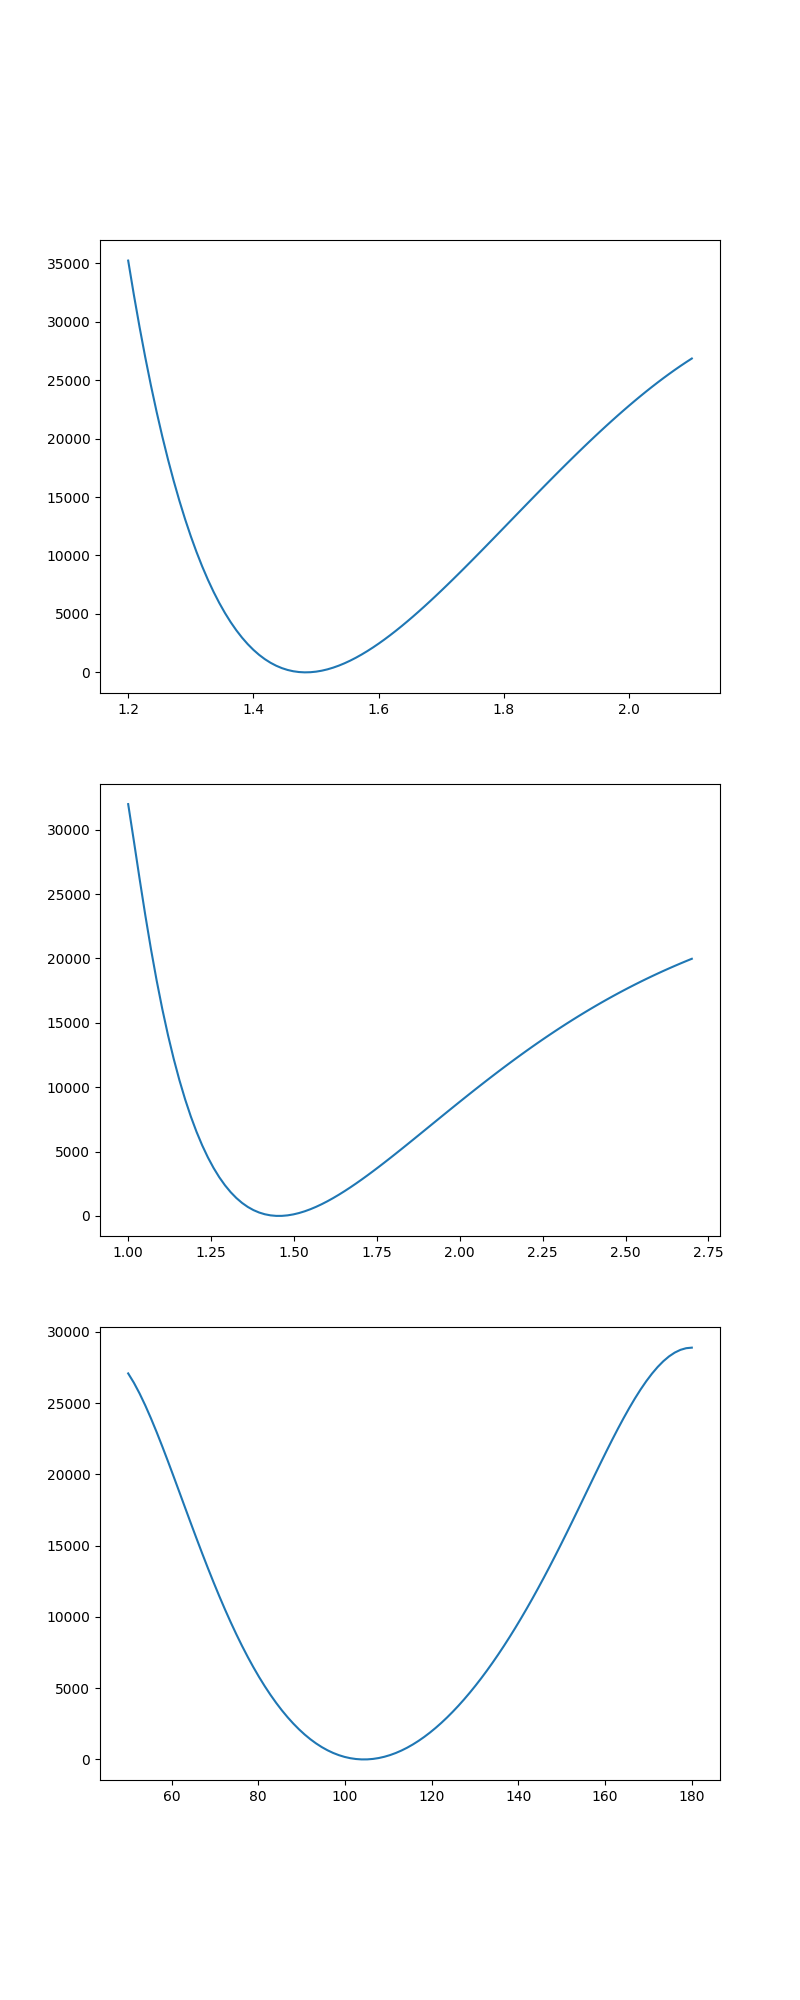

In [9]:
equilibriums = np.array([1.4839, 1.4551, 104.389])
coordinate_lower_bounds = [1.20, 1., 50]
coordinate_upper_bounds = [2.1, 2.7, 180]

geometry1d = np.zeros((100, 3))
for j in range(3):
    geometry1d[:, j] = nonlin_p_test[j]

fig, ax = plt.subplots(3,1, figsize=(8,20))

for i in range(3):
    geometry_1d = geometry1d.copy()
    geometry_1d[:, i] = np.linspace(coordinate_lower_bounds[i],
                                    coordinate_upper_bounds[i],
                                    100)
    ax[i].plot(geometry_1d[:, i], pes(geometry_1d))